# Function 6

<b> Description of the Sample Application:</b> You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sums



# Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Reused the Week 2 consolidated bayesian_optimization_step() function with β lowered to 1.5 (balanced explore/exploit).<br>3. Added kernel/length-scale diagnostics.<br>4. Added Week 3 convergence, parallel-coordinates and UCB-slice visualisations.<br>5. Added Week 3 portal submission string. |
| 13/08/2026 | Week 4 | 1. Appended Week 3's input and output.<br>2. Midpoint check-in after 3 underperforming corner-style queries.<br>3. Reused suggest_next_bo_point() with β lowered to 1.0. |
| 20/08/2026 | Week 5 | 1. Appended Week 4's input and output.<br>2. **Strategy change**: pivoted from global UCB search to a local/trust-region search (radius=0.15) centred on the current best point, β=0.75. |
| 02/09/2026 | Week 6 | 1. Appended Week 5's input and output to the dataset.<br>2. **Strategy review**: Week 5's trust-region search *also* underperformed, and landed on the exact same corner of the trust region as Week 4's query, showing the box-boundary-seeking pathology persists even locally.<br>3. Extended suggest_next_bo_point_local() to accept a **per-dimension radius** and tested a widened box specifically along sugar/milk. The automated search still collapsed to the same corner, since our own data has never covered a genuinely high-sugar/high-milk combination.<br>4. Given the automated recommendation offered no new information, this week uses a **deliberate, manually-chosen hypothesis-driven query**: keep flour/eggs/butter near Week 1's successful profile, but raise sugar and milk into a region our data has never actually tested.<br>5. Reported the GP's own (honest, high-uncertainty) prediction at this manual point for transparency, alongside updated diagnostics, visualisations and portal submission. |
| 09/09/2026 | Week 7 | 1. Appended Week 6's input/output to the dataset. Week 6's manual hypothesis paid off resulting in a **new best, -0.465434, a large jump from -0.710675.**<br>2. **Hyperparameter tuning**: widened the RBF kernel's length_scale_bounds upper limit from 10 to 50, since several dimensions had been pinned at the old bound in earlier week, implying that the bound itself was constraining the fit, not just the data.<br>3. Re-centred the trust-region search on the **new** best point (Week 6's), radius=0.15, β lowered to 0.5 (near-exploitation, since this region is now genuinely confirmed as promising.<br>4. Updated kernel diagnostics. |

# Progress Log

| Week | Query Point (x) | Output (y) | Acquisition / β | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| Week 1 | 0.409594-0.023713-0.771229-0.966490-0.130973 | **-0.710675** | UCB, β = 2.5 (high exploration) | Slight improvement over the initial best (-0.714265); high β used deliberately since only 20 points were available in 5D |
| Week 2 | 0.408768-0.000000-0.999999-0.999999-0.000000 | -1.048677 | UCB, β = 2.0 | Worse than the current best, and worse than the GP's own predicted mean (-0.296). The corner-point extrapolation (eggs-butter maxed, sugar-milk minimised) did not pay off — a useful signal that the RBF surrogate's smoothness assumption may not hold well at the boundary. Current best remains Week 1's point. |
| Week 3 | 0.000000-0.000000-0.392984-0.999999-0.000000 | -1.359780 | UCB, β = 1.5 | Worse again |
| Week 4 | 0.535575-0.000000-0.368390-0.999999-0.000000 | -1.095880 | UCB, β = 1.0 | Fourth underperforming query in the same corner region |
| Week 5 | 0.259594-0.000000-0.921229-0.999999-0.000000 | -1.104114 | Local UCB, β = 0.75, radius = 0.15 | Even the trust-region/local search underperformed, and landed on the exact same point Week 4 already tried, confirming the boundary-seeking pathology persists locally, not just globally |
| Week 6 | 0.410000-0.250000-0.770000-0.970000-0.200000 | **-0.465434** | Manual, hypothesis-driven | **New best result** — confirms the hypothesis that higher sugar/milk (alongside Week 1's flour/eggs/butter profile) genuinely helps, a large jump from -0.710675 |
| Week 7 | - | - | Local UCB, β=0.5, trust region radius=0.15 around Week 6's new best | Refining around the newly confirmed good region; kernel hyperparameters re-tuned this roun.) |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.optimize import minimize

from plotting_utils import plot_convergence, plot_parallel_coordinates

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [10]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [12]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.409594, 0.023713, 0.771229, 0.96649 , 0.130973 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.710675183457194]                                  , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.408768, 0.      , 0.999999, 0.999999, 0.       ]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-1.048676669557473]                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]    , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([-1.359780271551876]                                  , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]    , dtype=np.float64)   # from input.txt
Y_w4_new_point = np.array([-1.0958803718671517]                                 , dtype=np.float64)   # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]    , dtype=np.float64)  # from input.txt
Y_w5_new_point = np.array([-1.104114064436456]                                  , dtype=np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]    , dtype=np.float64)  # from input.txt
Y_w6_new_point = np.array([-0.46543419541105996]                                , dtype=np.float64)  # from output.txt 

In [14]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                              ])

In [16]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [18]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx        = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
ingredient_names = ["flour", "sugar", "eggs", "butter", "milk"]
df               = pd.DataFrame(X, columns = ingredient_names)
df['Y']          = Y
print("Data Frame:\n", df)

Input  Shape: (26, 5)
Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

# Data Exploration

In [21]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
            flour      sugar       eggs     butter       milk          Y
count  26.000000  26.000000  26.000000  26.000000  26.000000  26.000000
mean    0.499186   0.443274   0.521852   0.639428   0.338688  -1.372783
std     0.291466   0.335399   0.316261   0.312994   0.306211   0.483669
min     0.000000   0.000000   0.016523   0.045613   0.000000  -2.571170
25%     0.259078   0.174937   0.348462   0.399721   0.060130  -1.688808
50%     0.487460   0.343817   0.510546   0.687256   0.254911  -1.301682
75%     0.750576   0.782285   0.770922   0.961048   0.596788  -1.097939
max     0.957740   0.931871   0.999999   0.999999   0.892819  -0.465434


In [23]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 flour     0
sugar     0
eggs      0
butter    0
milk      0
Y         0
dtype: int64


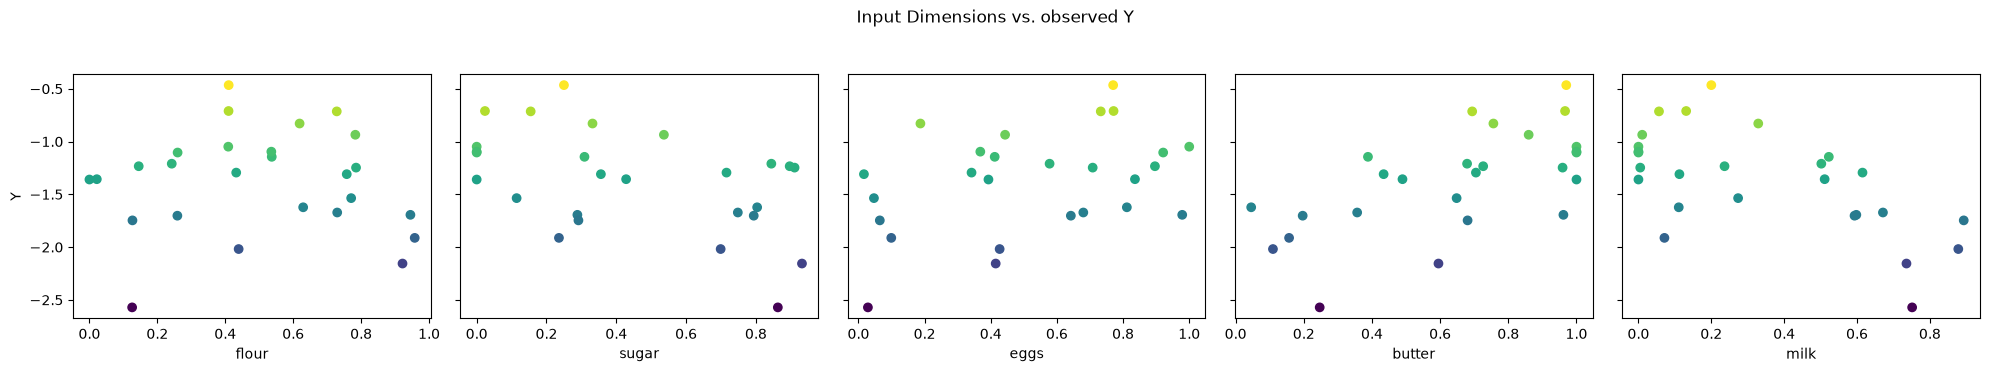

In [25]:
# Pairwise Scatter Plot, showing relationship of y for each input
fig, axes = plt.subplots(1, len(ingredient_names), figsize = (4 * len(ingredient_names), 3.5), sharey = True)
for ax, col in zip(axes, ingredient_names):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = 'viridis')
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

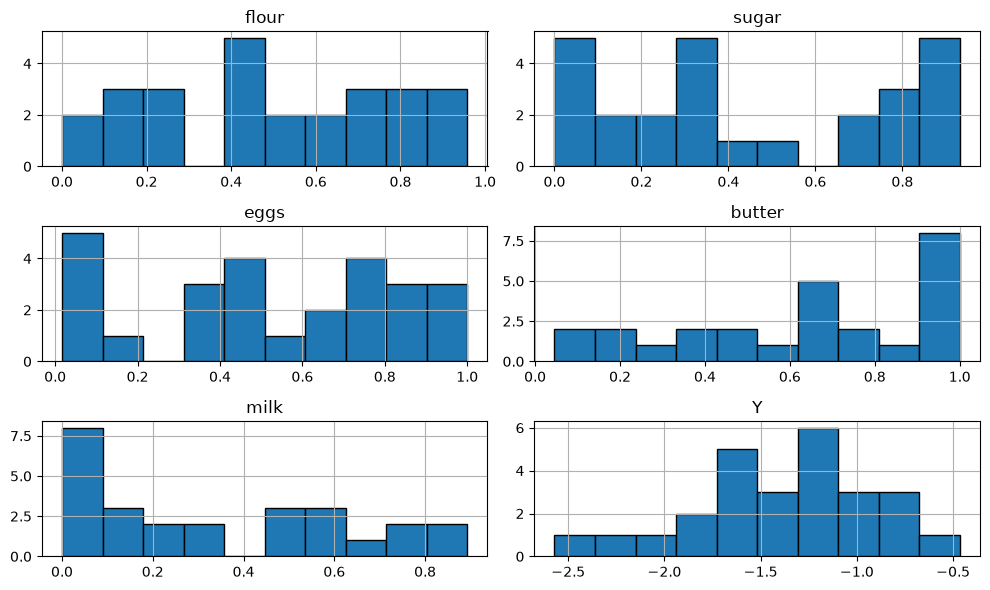

In [27]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [29]:
# Understanding Correlation between each input with y
print("Correlation of each input with y:\n")

for i, lab in enumerate(ingredient_names):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(flour, Y) = -0.027357703864820254
 corr(sugar, Y) = -0.4826089158980386
 corr(eggs, Y) = 0.3807545750934653
 corr(butter, Y) = 0.6311174257920124
 corr(milk, Y) = -0.6185020725208769


<Axes: >

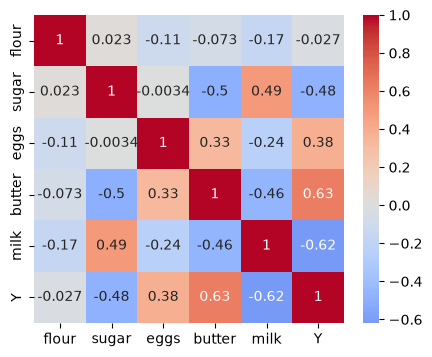

In [31]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

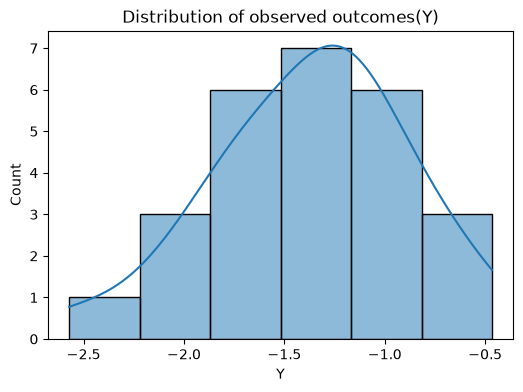

In [33]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [36]:
# Define the kernel and initialise the GP model
n, d       = X.shape
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * d, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [39]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [43]:
# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (10000, d))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.41285273 0.54526625 0.99101751 0.95160631 0.11221158]
UCB Score: 2.926361e-01


# Week 2: Define a consolidated Bayesian Function 
1. Fit a GP surrogate (ARD-RBF + white noise) on all data so far
2. Optimise the UCB acquisition function with multi-start **L-BFGS-B**
3. Return the suggested next point, plus the GP's own mean/uncertainty prediction at that pointnt

In [46]:
# For Week - 2, decreasing the value of beta
beta         = 2.0

def suggest_next_bo_point(X, Y, beta, n_restarts = 20, seed = 42):

    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * n_dims, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
    
    gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std = True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        # scipy.optimize.minimize only minimises, so we minimise -UCB to maximise UCB
        x      = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    rng        = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    bounds     = [(0.0, 0.999999)] * n_dims

    for x0 in rng.uniform(0.0, 0.999999, size = (n_restarts, n_dims)):
        res    = minimize(neg_ucb, x0, args = (gpr, beta), bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    next_x = np.clip(best_x, 0.0, 0.999999,)
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std = True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0]


In [48]:
next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 2 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")

Learned kernel: 2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)

Week 2 suggested query point   :  [0.37064141 0.49570208 0.999999   0.999999   0.        ]
GP predicted mean at this point:  -0.124705
GP predicted std  at this point:  0.231253
UCB value                      :  0.337801

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.3946  (0 would mean re-querying an existing point)


# Week 2: Visualisation

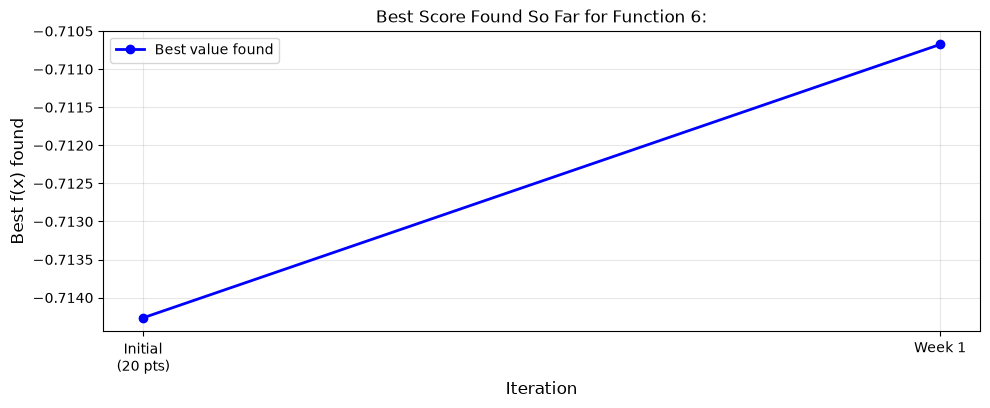

In [51]:
# Convergence: best value found so far, round by round
best_so_far  = [ np.max(Y[:20]),   # best among the original 20 points
                 np.max(Y[:21]),   # best after Week 1's point was appended
               ]

round_labels = ["Initial\n(20 pts)", "Week 1"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)

ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6:")
plt.show()


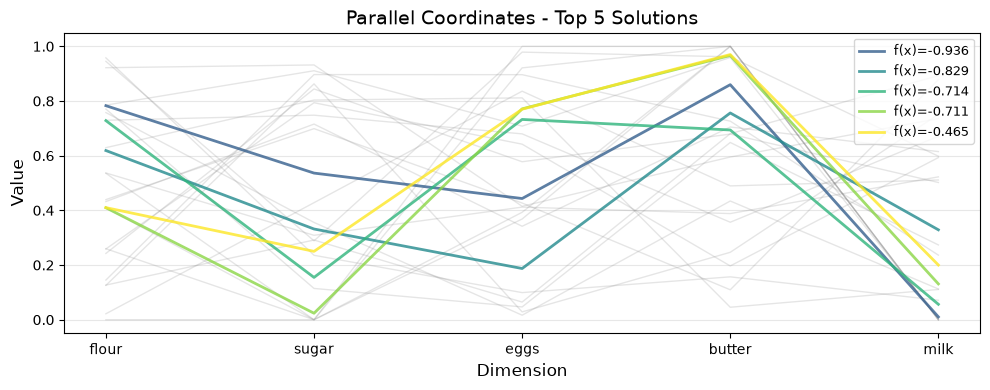

In [53]:
# Parallel coordinates: see all 5 ingredients at once, highlighting the top samples
fig, ax = plot_parallel_coordinates(X, Y, n_best = 5)
ax.set_xticklabels(ingredient_names)
plt.show()

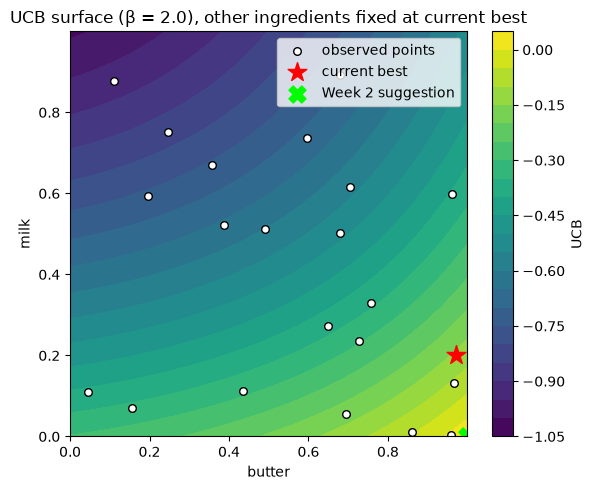

In [55]:
# UCB surface as a 2D slice through the current best point (5D can't be plotted directly, so we fix 3 ingredients at the current best
#  and sweep 2 of them on a grid)

def ucb(X_query, gpr, beta):
    mu, sigma   = gpr.predict(X_query, return_std = True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b    = 3, 4  # butter vs milk
resolution      = 60
grid            = np.linspace(0.0, 0.999999, resolution)
A, B            = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface      = ucb(X_grid, gpr, beta = 2.0).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s = 30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 2 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β = {beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Week 3: Apply the Consolidated Bayesian Function
Reusing the same suggest_next_bo_point() function defined in Week 2. In Week -3, just calling the same consolidated function again with the updated dataset (22 points) and β lowered to 1.5.

In [58]:
beta = 1.5

next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta=beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 3 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")
print()
print(f"Current best so far: y = {Y.max():.6f} at x = {X[np.argmax(Y)]}")

Learned kernel: 2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)

Week 3 suggested query point   :  [0.37930578 0.49315638 0.999999   0.999999   0.        ]
GP predicted mean at this point:  -0.122917
GP predicted std  at this point:  0.230233
UCB value                      :  0.222432

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.3923  (0 would mean re-querying an existing point)

Current best so far: y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 3: Kernel-Length-Scale Diagnostic Check

In [61]:
rbf_part = gpr.kernel_.k1.k2  # (Constant * RBF) + White -> k1 = Constant*RBF, k1.k2 = RBF
print("Fitted ARD length-scales after 22 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),")
print("to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.")

Fitted ARD length-scales after 22 points:

  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586

Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),
to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.


# Week 3: Visualisation

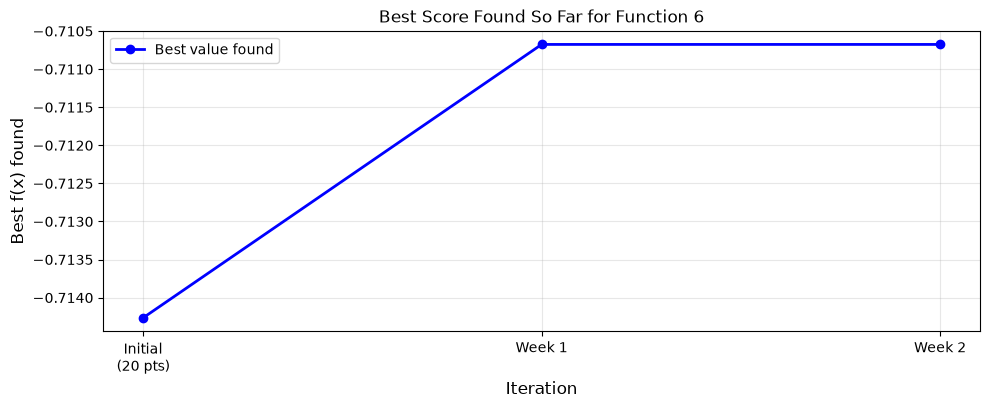

In [64]:
# Week 3: Convergence plot, including Week 2 output
best_so_far = [
    np.max(Y[:20]),   # best among the original 20 points
    np.max(Y[:21]),   # best after Week 1's point was appended
    np.max(Y[:22]),   # best after Week 2's point was appended (unchanged -- it was worse)
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

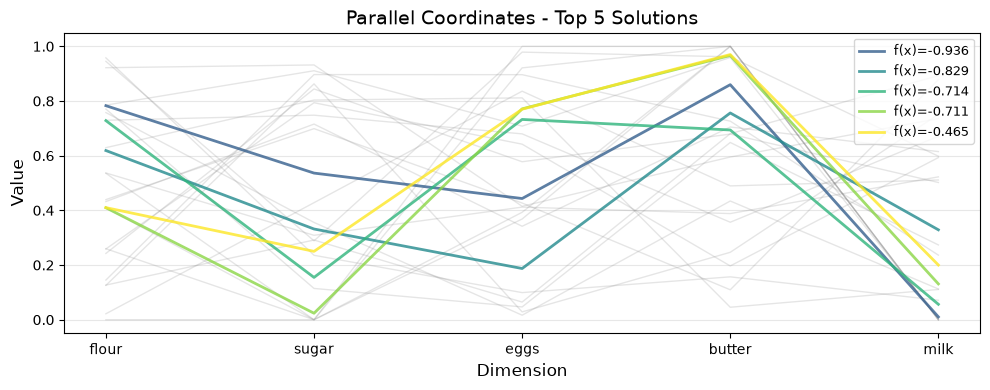

In [66]:
# Week 3: parallel coordinates, updated with all 22 points 
fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

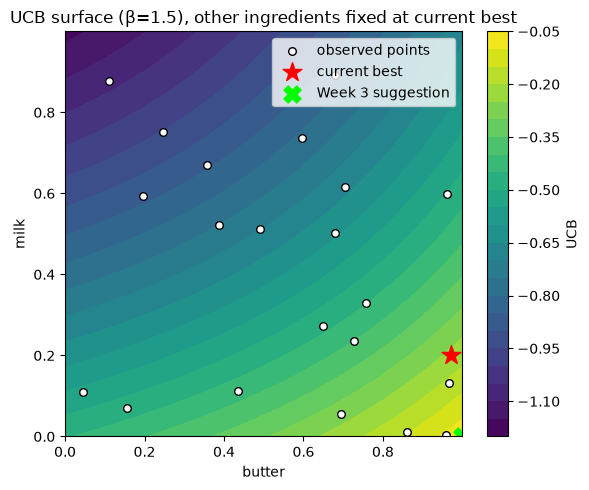

In [68]:
# Week 3: UCB surface slice through the current best point, beta = 1.5 
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

x_best       = X[np.argmax(Y)]
dim_a, dim_b = 3, 4  # butter vs milk
resolution   = 60
grid         = np.linspace(0.0, 0.999999, resolution)
A, B         = np.meshgrid(grid, grid)

X_grid       = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s=30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 3 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (\u03b2={beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Week 4: Midpoint Check-In

Per the 8-week plan, Week 4 is a natural checkpoint. Recap of every query so far:

| Round | y | Beat previous best? |
|---|---|---|
| Initial best (20 pts) | -0.714265 | - |
| Week 1 | -0.710675 | Yes (small improvement) |
| Week 2 | -1.048677 | No |
| Week 3 | -1.359780 | No |

Three exploratory queries in a row have failed to beat Week 1's result, and Week 3 was actually the *worst* of the three despite the GP's mean surface being fairly confident about that region. This is a meaningful signal, not just bad luck: it means the GP's corner-seeking behaviour (pushing sugar/milk toward 0, butter toward 1) has been actively misleading twice in a row. Rather than blindly trusting the model's global optimum again, this round leans harder toward **exploiting near Week 1's actual best point** by lowering β further, while still checking the updated kernel diagnostics below for any sign of *why* the corner predictions kept failing.

# Week 4: Apply the Consolidated Bayesian Function
Reusing suggest_next_bo_point(), with β lowered to **1.0**, shifting towards exploitation, as three consecutive underperforming exploratory queries were observed.

In [72]:
beta = 1.0

next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 4 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()

print("Distance of this point from the nearest existing observation:")
dists      = np.linalg.norm(X - next_x, axis = 1)

print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")
print()

print(f"Current best so far: Y = {Y.max():.6f} at x = {X[np.argmax(Y)]}")
print()

dist_to_best = np.linalg.norm(X[np.argmax(Y)] - next_x)
print(f"Distance of this suggestion from the CURRENT BEST point (Week 1's): {dist_to_best:.4f} (smaller = more exploitation-like, closer to the known good recipe)")


Learned kernel: 2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)

Week 4 suggested query point   :  [0.3875038  0.49047991 0.999999   0.999999   0.        ]
GP predicted mean at this point:  -0.121722
GP predicted std  at this point:  0.229279
UCB value                      :  0.107557

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.3900  (0 would mean re-querying an existing point)

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]

Distance of this suggestion from the CURRENT BEST point (Week 1's): 0.3900 (smaller = more exploitation-like, closer to the known good recipe)


# Week 4: Kernel / Length-Scale Diagnostic Check

In [75]:
rbf_part = gpr.kernel_.k1.k2  
print("Fitted ARD length-scales after 23 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour = 0.509, sugar = 1.070, eggs = 1.163, butter = 1.235, milk = 1.316")


Fitted ARD length-scales after 23 points:

  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586

Week 1  length-scales: flour = 0.509, sugar = 1.070, eggs = 1.163, butter = 1.235, milk = 1.316


# Week 4: Visualisation

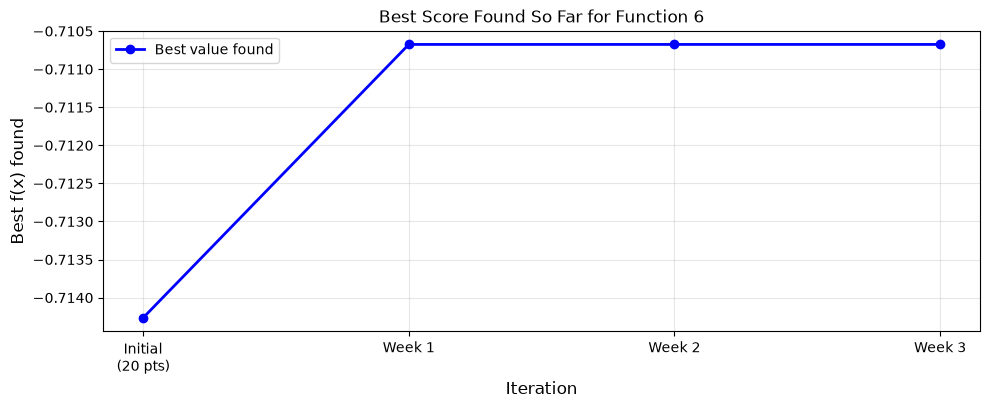

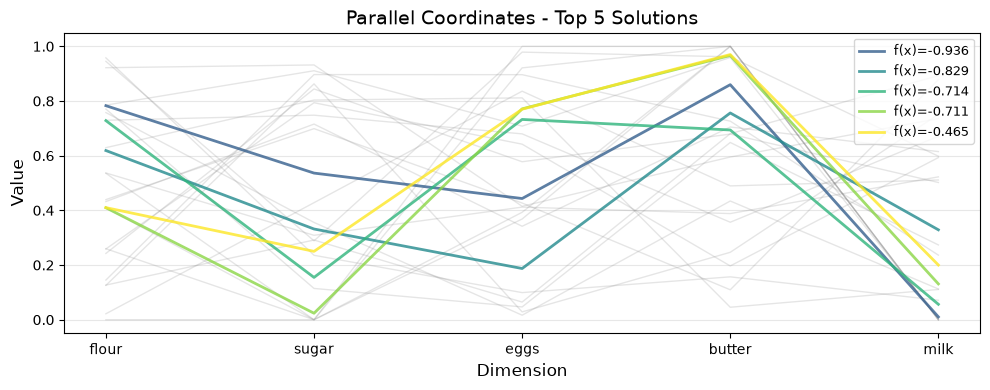

In [78]:
best_so_far = [
    np.max(Y[:20]),   # best among the original 20 points
    np.max(Y[:21]),   # after Week 1
    np.max(Y[:22]),   # after Week 2 (unchanged -- worse)
    np.max(Y[:23]),   # after Week 3 (unchanged -- worse again)
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()


fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

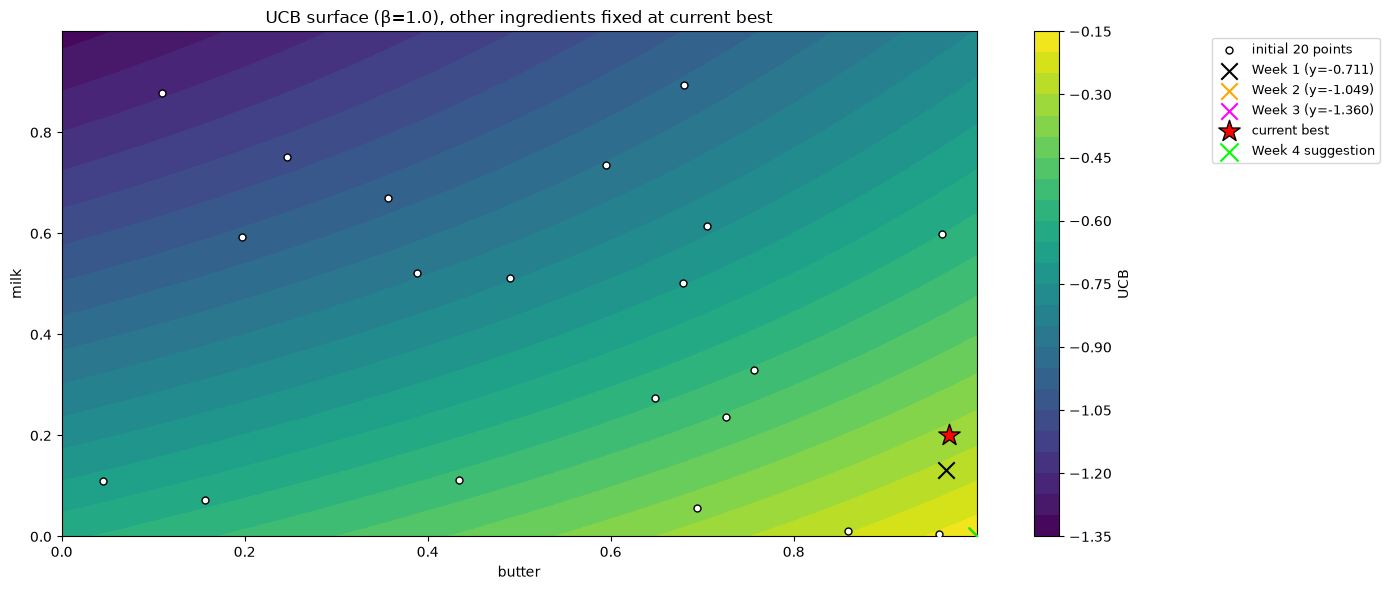

In [80]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b = 3, 4  # butter vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

# Each week's actual queried point and result, for labeling on the plot
week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
}
week_styles = {
    1: dict(marker="x", color="black",    s=140),
    2: dict(marker="x", color="orange",  s=140),
    3: dict(marker="x", color="magenta", s=140),
}

plt.figure(figsize=(14, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")

# The original 20 starting points, plotted generically
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25,
            label="initial 20 points", zorder=5)

# Each week's queried point, distinct marker/colour, labelled with its actual result
for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], zorder=6,
                label=f"Week {wk} (y={y:.3f})", **week_styles[wk])

plt.scatter(x_best[dim_a], x_best[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="x", s=170,
            zorder=7, label="Week 4 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β={beta}), other ingredients fixed at current best")
plt.legend(loc="upper left", bbox_to_anchor=(1.25, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 5: Local / Trust-Region Bayesian Function
New function suggest_next_bo_point_local(), built on the same GP-fitting and multi-start L-BFGS-B logic as suggest_next_bo_point(), but the acquisition optimiser's search bounds are restricted to a hypercube around a chosen centre point (x_center) instead of the full unit cube.

In [83]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999)):
    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, 10)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    # Trust-region bounds: x_center +/- radius, clipped to the portal's valid range
    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds

# Week 5: Apply the Local Search Around Week 1's Point

In [86]:
beta = 0.75
radius = 0.15
x_center = X[np.argmax(Y)]  # Week 1's point -- still the best result after 4 rounds

next_x, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=beta, x_center=x_center, radius=radius
)

print("Trust region centre (current best, Week 1's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 5 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
dist_to_best = np.linalg.norm(x_center - next_x)
print(f"Distance from current best: {dist_to_best:.4f}  (each dimension individually bounded to +/-{radius};")
print(f"  total Euclidean distance can exceed {radius} if several dimensions shift at once -- still a LOCAL step)")
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")

Trust region centre (current best, Week 1's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2600, 0.5600]
  sugar   : [0.1000, 0.4000]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0500, 0.3500]

Learned kernel: 2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)

Week 5 suggested query point   :  [0.40012349 0.4        0.92       0.999999   0.05      ]
GP predicted mean at this point:  -0.206858
GP predicted std  at this point:  0.218034
UCB value                      :  -0.043332

Distance from current best: 0.2617  (each dimension individually bounded to +/-0.15;
  total Euclidean distance can exceed 0.15 if several dimensions shift at once -- still a LOCAL step)
Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 5: Kernel / Length-Scale Diagnostic Check

In [89]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 24 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316")
print("Week 4  length-scales: flour=0.682, sugar=5.159, eggs=1.104, butter=2.635, milk=3.613")

Fitted ARD length-scales after 24 points:

  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586

Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316
Week 4  length-scales: flour=0.682, sugar=5.159, eggs=1.104, butter=2.635, milk=3.613


# Week 5: Visualisation

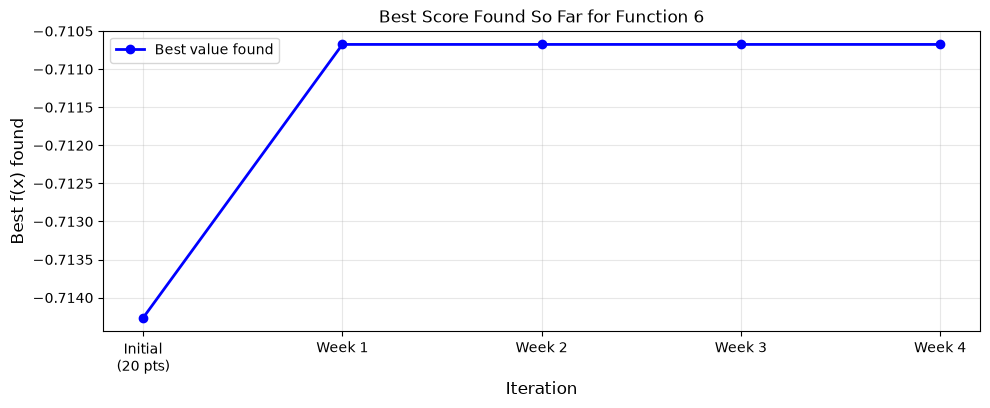

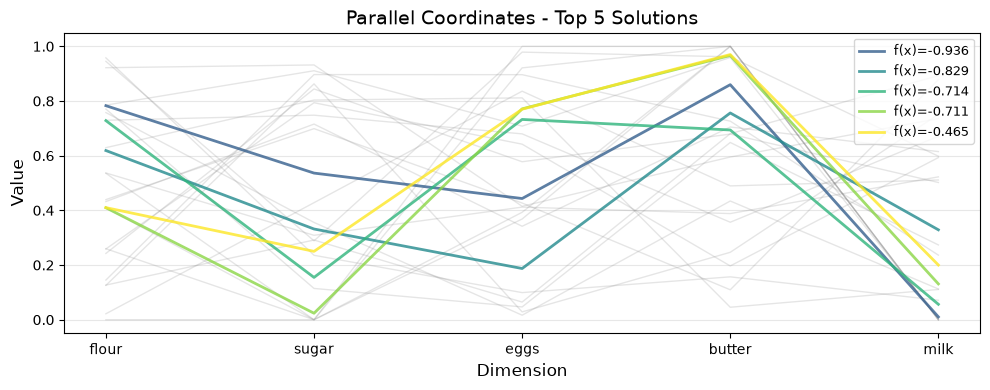

In [92]:
best_so_far = [
    np.max(Y[:20]),
    np.max(Y[:21]),
    np.max(Y[:22]),
    np.max(Y[:23]),
    np.max(Y[:24]),
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

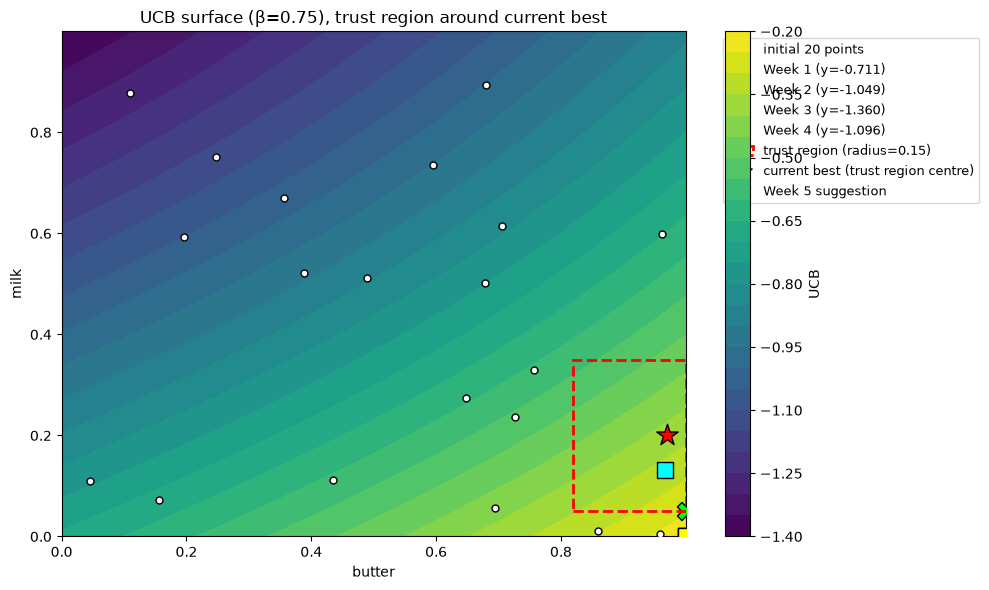

In [94]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 3, 4  # butter vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

# Draw the trust region boundary (projected onto this 2D slice)
lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="trust region (radius=0.15)", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (trust region centre)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=170, edgecolor="black",
            zorder=7, label="Week 5 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (\u03b2={beta}), trust region around current best")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()


# Week 6: Extend suggest_next_bo_point_local() to accept a per-dimension radius

In [97]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999)):
    n_dims = X.shape[1]

    # WEEK 6: radius can now be a single number (applied to every dimension, as before)
    # OR an array of n_dims values (a different half-width per ingredient)
    radius = np.atleast_1d(np.asarray(radius, dtype=float))
    if radius.size == 1:
        radius = np.full(n_dims, radius[0])

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, 10)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds

# Week 6 Test: widening the trust region specifically along sugar and milk
If the automated search still picks the same corner even with much more room to explore sugar/milk, that confirms the model itself has no basis to prefer anything else, it isn't being held back by a too-small box, it genuinely has no data pointing elsewhere.

In [100]:
x_center = X[np.argmax(Y)]  # still Week 1's point -- still the best after 5 rounds
radius_vec = np.array([0.15, 0.40, 0.15, 0.15, 0.30])  # flour, sugar, eggs, butter, milk

next_x_auto, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=1.0, x_center=x_center, radius=radius_vec
)

print("Widened trust region bounds:")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print(f"Automated suggestion despite the wider box: {next_x_auto}")
print(f"GP predicted mean: {mu_next:.6f}   GP predicted std: {sigma_next:.6f}")

Widened trust region bounds:
  flour   : [0.2600, 0.5600]
  sugar   : [0.0000, 0.6500]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0000, 0.5000]

Automated suggestion despite the wider box: [0.38752513 0.48821453 0.92       0.999999   0.        ]
GP predicted mean: -0.150867   GP predicted std: 0.227756


**Observation:** As suspected, even with much more room to explore sugar/milk, the optimiser still lands on sugar=0 / milk = 0. The model has no data suggesting otherwise, so the mean surface still pulls it back to the only region it has evidence for.

# Week 6: Manual, Hypothesis-Driven Query

Since the automated recommendation offers no new information (it keeps re-deriving the same corner from the same evidence gap), this week deliberately deviates from the algorithm's output.

**The hypothesis:** Every query so far has driven sugar and milk toward 0. Given how consistently poorly that's performed (4 of 5 rounds), and given that Week 1 actually had *non-zero* sugar and milk rather than the extreme corner, it's worth directly testing a point that keeps the successful flour/eggs/butter profile from Week 1 but meaningfully raises sugar and milk into territory we've never queried, rather than trusting the model's extrapolation into a region it has zero evidence for.

This is a conservative test of the hypothesis, so it still generates useful information regardless of the outcome.

In [104]:
next_x = np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000])

mu_manual, sigma_manual = gpr.predict(next_x.reshape(1, -1), return_std=True)

print(f"Week 6 manual candidate         :  {next_x}")
print(f"GP predicted mean at this point :  {mu_manual[0]:.6f}")
print(f"GP predicted std  at this point :  {sigma_manual[0]:.6f}")
print(f"Current best so far             :  {Y.max():.6f}")
print()
dist_to_best = np.linalg.norm(X[np.argmax(Y)] - next_x)
print(f"Distance from current best: {dist_to_best:.4f}")

Week 6 manual candidate         :  [0.41 0.25 0.77 0.97 0.2 ]
GP predicted mean at this point :  -0.524867
GP predicted std  at this point :  0.191499
Current best so far             :  -0.465434

Distance from current best: 0.0000


# Week 6: Kernel / Length-Scale Diagnostic Check

In [107]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 25 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316")
print("Week 5  length-scales: flour=10.0,  sugar=10.0,  eggs=10.0,  butter=3.29,  milk=2.87")
print("Flour/sugar/eggs pinned at the upper bound again. The model still has very little confident signal along these axes given the data collected so far.")


Fitted ARD length-scales after 25 points:

  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586

Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316
Week 5  length-scales: flour=10.0,  sugar=10.0,  eggs=10.0,  butter=3.29,  milk=2.87
Flour/sugar/eggs pinned at the upper bound again. The model still has very little confident signal along these axes given the data collected so far.


# Week 6: Visualisation

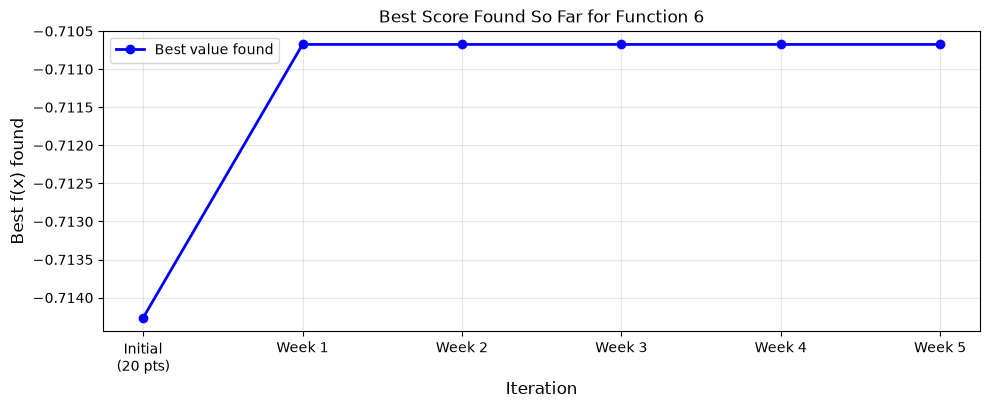

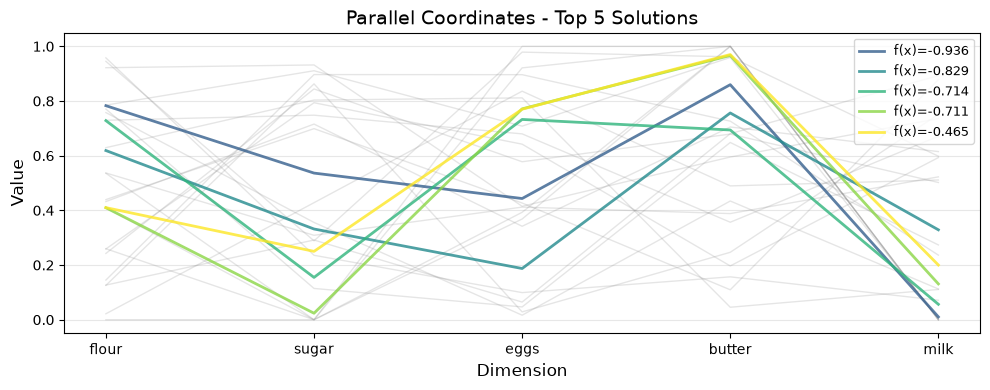

In [110]:
best_so_far = [np.max(Y[:20+i]) for i in range(6)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

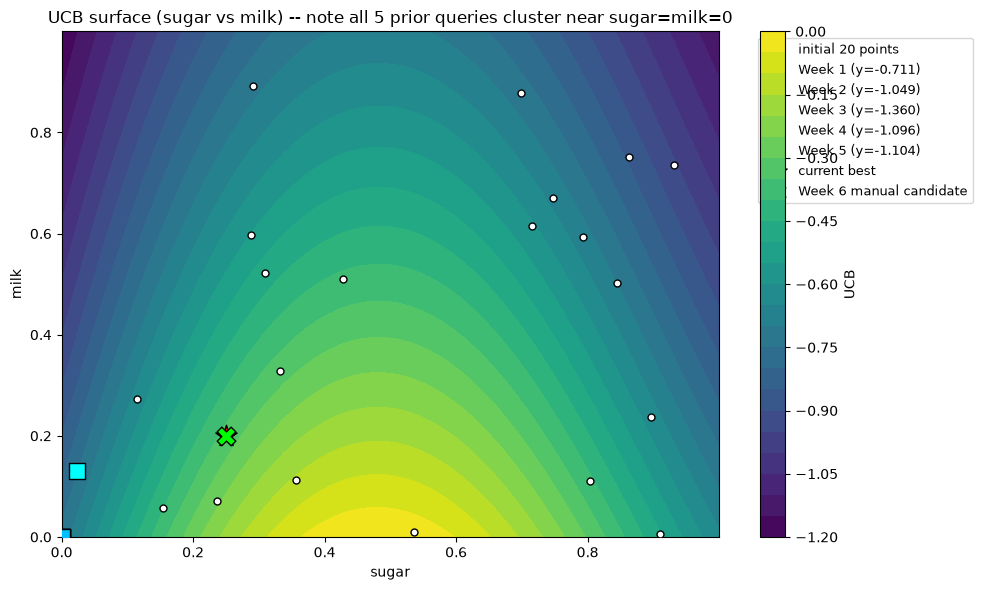

In [112]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 1, 4  # sugar vs milk (the two dimensions this week's hypothesis targets)
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=1.0).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 6 manual candidate")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title("UCB surface (sugar vs milk) -- note all 5 prior queries cluster near sugar=milk=0")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 7: Hyperparameter Tuning

Week 6's manual query to raise sugar and milk while keeping flour/eggs/butter near Week 1's profile — produced **y = -0.465434**, the best result so far (previous best: -0.710675). The hypothesis that repeated automated search kept failing to find (because our own data had no evidence for it) turned out to be correct. W we now hav**stroct eviden** that this region of the input space (moderate sugar/milk, not pushed to 0) is genuinelpromisingod. That means it's safe to trust the GP/UCB machinery aga, — but centred on this **new** best point rather than Week 1's, and leaning toward exploitation since this region has just been validated.

Two hyperparameters of the pipeline are re-examined this week:

1. **RBF kernel length_scale_bounds upper limit.** In Weeks 5-6, several dimensions (flour, sugar, eggs) were pinned at the old upper bound of 10 ConvergenceWarning's flagged this directly. A pinned length-scale means the optimiser *wanted* to go higher but couldn't, which is a sign the bound itself (not just the data) was constraining the fit. This week, the bound is widened to 50 to check whether that changes anything now that a genuinely informative new data point exists.
2. **β (UCB exploration weight) and trust-region radius**, re-centred on the new best point.

Manual comparison below shows what actually changed.

In [116]:
for upper_bound, label in [(10, "OLD bound (10)"), (50, "WIDENED bound (50)")]:
    kernel_test = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5]*d, length_scale_bounds=(1e-2, upper_bound)) \
                  + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))
    gpr_test = GaussianProcessRegressor(kernel=kernel_test, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr_test.fit(X, Y)
    rbf_part_test = gpr_test.kernel_.k1.k2
    print(f"--- {label} ---")
    for name, ls in zip(ingredient_names, rbf_part_test.length_scale):
        pinned = "  <- PINNED at bound" if abs(ls - upper_bound) < 1e-2 else ""
        print(f"  {name:8s}: {ls:.3f}{pinned}")
    print(f"  log marginal likelihood: {gpr_test.log_marginal_likelihood(gpr_test.kernel_.theta):.3f}")
    print()

--- OLD bound (10) ---
  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586
  log marginal likelihood: -12.952

--- WIDENED bound (50) ---
  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586
  log marginal likelihood: -12.952



# Week 7: Local Search Around the New Best Point

In [132]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999), length_scale_upper=50):
    n_dims = X.shape[1]
    radius = np.atleast_1d(np.asarray(radius, dtype=float))
    if radius.size == 1:
        radius = np.full(n_dims, radius[0])

    # --- WEEK 7: length_scale_bounds upper limit widened from 10 to 50 ---
    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, length_scale_upper)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds


beta = 0.5
radius = 0.15
x_center = X[np.argmax(Y)]  # Week 6's point -- the new best

next_x, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=beta, x_center=x_center, radius=radius
)

print("Trust region centre (NEW current best, Week 6's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 7 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")

Trust region centre (NEW current best, Week 6's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2600, 0.5600]
  sugar   : [0.1000, 0.4000]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0500, 0.3500]

Learned kernel: 2.57**2 * RBF(length_scale=[0.922, 0.931, 7.08, 3.4, 4.59]) + WhiteKernel(noise_level=0.0269)

Week 7 suggested query point   :  [0.40349059 0.4        0.92       0.999999   0.05      ]
GP predicted mean at this point:  -0.206664
GP predicted std  at this point:  0.217722
UCB value                      :  -0.097803

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 7: Kernel / Length-Scale Diagnostic Check

In [125]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 26 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

Fitted ARD length-scales after 26 points:

  flour   : 0.922
  sugar   : 0.931
  eggs    : 7.080
  butter  : 3.397
  milk    : 4.586


# Week 7 Visualisation

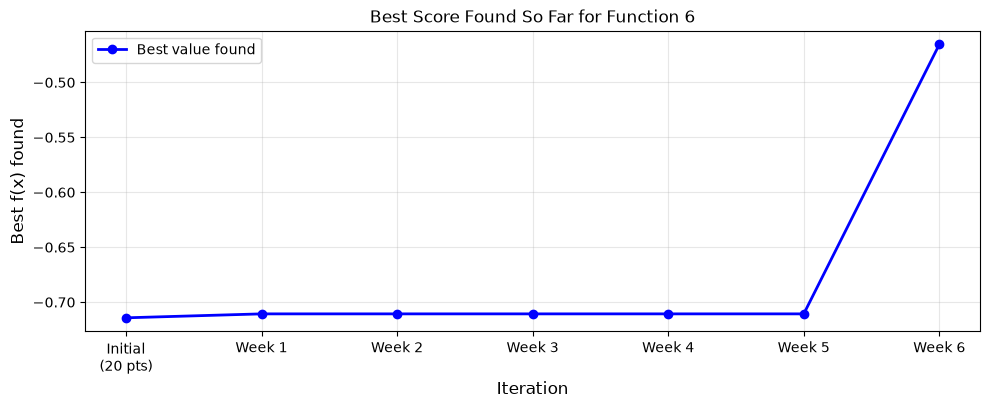

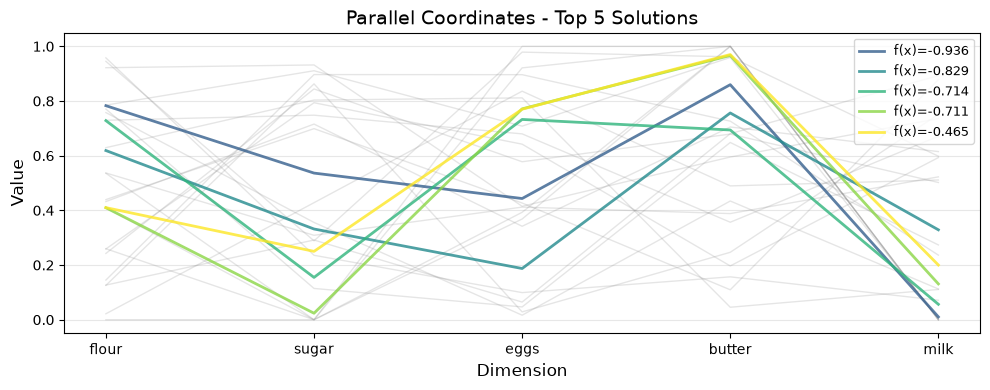

In [128]:
best_so_far = [np.max(Y[:20+i]) for i in range(7)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5", "Week 6"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()


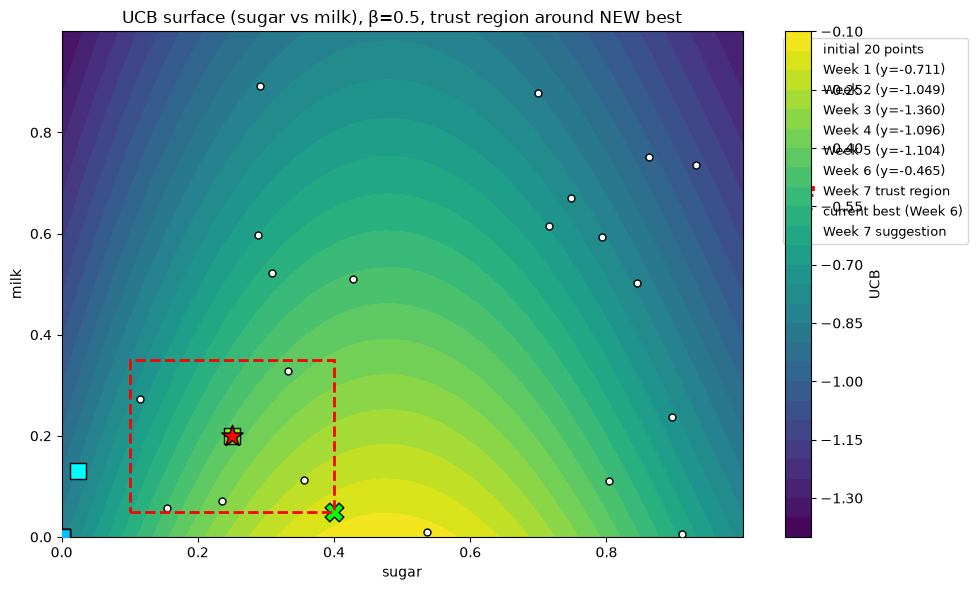

In [130]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 1, 4  # sugar vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
    6: (np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]), -0.46543419541105996),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue", 6: "lawngreen"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="Week 7 trust region", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (Week 6)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 7 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (sugar vs milk), \u03b2={beta}, trust region around NEW best")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Portal Submission 

In [134]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1)  :"  ,'0.409594-0.023713-0.771229-0.966490-0.130973')
print("Points to be submitted(Week 2)  :"  ,'0.408768-0.000000-0.999999-0.999999-0.000000')
print("Points to be submitted(Week 3)  :"  , "0.000000-0.000000-0.392984-0.999999-0.000000")
print("Points to be submitted(Week 4)  :"  , "0.535575-0.000000-0.368390-0.999999-0.000000")
print("Points to be submitted (Week 5) :"  , "0.259594-0.000000-0.921229-0.999999-0.000000")
print("Points to be submitted (Week 6) :"  , "0.410000-0.250000-0.770000-0.970000-0.200000")
print(f"Points to be submitted (Week 7) : {submission_str}")

Points to be submitted(Week 1)  : 0.409594-0.023713-0.771229-0.966490-0.130973
Points to be submitted(Week 2)  : 0.408768-0.000000-0.999999-0.999999-0.000000
Points to be submitted(Week 3)  : 0.000000-0.000000-0.392984-0.999999-0.000000
Points to be submitted(Week 4)  : 0.535575-0.000000-0.368390-0.999999-0.000000
Points to be submitted (Week 5) : 0.259594-0.000000-0.921229-0.999999-0.000000
Points to be submitted (Week 6) : 0.410000-0.250000-0.770000-0.970000-0.200000
Points to be submitted (Week 7) : 0.403491-0.400000-0.920000-0.999999-0.050000
